In [2]:
# %%
# Analyze the flow data to identify the peak flow and its timing during the flood event
from PIL.Image import logger
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import glob

import rasterio


PROJECT_ROOT = "/home/91/23016891/projects/carlisle"
BC_DATA_DIR = f"/data/carlisle/simulation/"
GRAPH_OUTPUT_DIR = f"{PROJECT_ROOT}/out"
FLOOD_MAPS_DIR  = "/data/carlisle/simulation/"


def create_indices():
    event_index = {
        1: "Run1",
        2: "Run2",   
        3: "Run3",
        4: "Run4",
        5: "Run5",
        6: "Run6",
        7: "Run7",
        8: "Run8",
        9: "Run9",  
    }
    event_name_map = {
        "Run1": "Run1",
        "Run2": "Run2",
        "Run3": "Run3",
        "Run4": "Run4",
        "Run5": "Run5",
        "Run6": "Run6",
        "Run7": "Run7",
        "Run8": "Run8",
        "Run9": "Run9"
    }
    return event_index, event_name_map
event_index_map, event_name_map = create_indices()


def extract_timestep_from_filename(filename):
    try:
        timestep_str = filename.split("-")[1].split(".wd")[0]
        timestep_dt = int(timestep_str)
        return timestep_dt
    except Exception as e:
        logger.error(f"Error extracting timestep from filename {filename}: {e}")
        return None

    
def preprocess_boundary_conditions_carlisle( event_ids):
        event_input_map = {}

        for event_id in event_ids:
            inflow_file = os.path.join(BC_DATA_DIR, f"Upstream_Flows_Run{event_id}.csv")
            inflow_data = pd.read_csv(inflow_file)
            event_index = event_index_map[event_id]
              
            flood_map_files = glob.glob(os.path.join(FLOOD_MAPS_DIR, f"{event_name_map[event_index]}", "Run*.wd"))
            flood_map_files.sort()
            
            # Extract the timestamp from the flood map file names and store in a list
            flood_map_timestamps = [extract_timestep_from_filename(file) for file in flood_map_files]
            logger.info(f"Extracted {len(flood_map_timestamps)} flood map   timestamps for event ID: {event_id}")
            inflow_data['timestep'] = (inflow_data['Time'].astype(np.float32) / (60 * 15)).astype(np.float32)
            # Use only a single timestep column (no lagged timestep-* columns)
            time_columns = ['timestep']
            inflow_data['flood_map_file'] = inflow_data['timestep'].apply(lambda x: next((file for file in flood_map_files if int(extract_timestep_from_filename(file)) == int(x)), None))

            # Remove first 8 rows as first 8 timesteps represent the intialisation period. 
            inflow_data = inflow_data.iloc[8:]
            

            inflow_data = inflow_data.dropna()
            inflow_data = inflow_data.drop(columns=['Time'])
            
            event_input_map[event_id] = inflow_data
        return event_input_map  
    
event_input_map = preprocess_boundary_conditions_carlisle(event_ids=list(event_index_map.keys()))
#save the event input map to a csv file for later use
for event_id, inflow_data in event_input_map.items():
    output_file = os.path.join(GRAPH_OUTPUT_DIR, "carlisle", f"event_{event_id}.csv")
    inflow_data.to_csv(output_file, index=False)
    logger.info(f"Saved event input map for event ID {event_id} to {output_file}")

In [18]:
import torch


def analyze_events():
    
    event_peaks = {}
    #analyse peak flow and its timing for each event
    for event_id, inflow_data in event_input_map.items():
        #there are three boundary conditions: Upstream1, Upstream2 and Upstream3.
        # We will analyze the peak flow and its timing for each of these boundary conditions.
        
        peak_flow_up1 = inflow_data['Upstream1'].max()
        peak_timestep_up1 = inflow_data.loc[inflow_data['Upstream1'] == peak_flow_up1, 'timestep'].iloc[0]

        peak_flow_up2 = inflow_data['Upstream2'].max()
        peak_timestep_up2 = inflow_data.loc[inflow_data['Upstream2'] == peak_flow_up2, 'timestep'].iloc[0]
        
        peak_flow_up3 = inflow_data['Upstream3'].max()
        peak_timestep_up3 = inflow_data.loc[inflow_data['Upstream3'] == peak_flow_up3, 'timestep'].iloc[0]
        
        peak_flow = max(peak_flow_up1, peak_flow_up2, peak_flow_up3)
        event_duration_hours = (inflow_data['timestep'].max() - inflow_data['timestep'].min()) * 0.25  #Since each timestep is 15 minutes
        number_of_timesteps = len(inflow_data)
        logger.info(f"Event ID: {event_id}, Event Name: {event_name_map[event_index_map[event_id]]}, Event Duration: {event_duration_hours} hours")
        event_peaks[event_id] = {
            "number_of_timesteps": number_of_timesteps,
            "peak_flow_up1": peak_flow_up1,
            "peak_flow_up2": peak_flow_up2,
            "peak_flow_up3": peak_flow_up3,
            "peak_timestep_up1": peak_timestep_up1,
            "peak_timestep_up2": peak_timestep_up2,
            "peak_timestep_up3": peak_timestep_up3,
            "event_duration_hours": event_duration_hours
        }
        
        
    #find study domain size and resolution from the flood maps of the first event
    first_event_flood_maps = glob.glob(f"{FLOOD_MAPS_DIR}/{event_name_map[event_index_map[1]]}/Run*.wd")
    if first_event_flood_maps:
        with rasterio.open(first_event_flood_maps[0]) as src:
            domain_width = src.width
            domain_height = src.height
            resolution = src.res[0]  # Assuming square pixels
            print(f"Study domain size: {domain_width} x {domain_height} pixels, Resolution: {resolution} meters/pixel")
    else:
        print("No flood maps found for the first event.")

    volume_peaks = {}
    for event_id, inflow_data in event_input_map.items():
        flood_map_files = inflow_data['flood_map_file'].dropna().tolist()
        valid_rows      = inflow_data[inflow_data['flood_map_file'].notna()].reset_index(drop=True)
        
        chunk_size  = 20
        all_volumes = []

        for i in range(0, len(flood_map_files), chunk_size):
            if i + chunk_size > len(flood_map_files):
                chunk_size = len(flood_map_files) - i
            chunk_files = flood_map_files[i:i + chunk_size]

            arrays = []
            for f in chunk_files:
                with rasterio.open(f) as src:
                    arrays.append(src.read(1))

            batch = torch.from_numpy(np.stack(arrays, axis=0)).float().cuda()
            batch = torch.nan_to_num(batch, nan=0.0).clamp(min=0.0)

            volumes = batch.sum(dim=(1, 2)) * (resolution ** 2)
            all_volumes.append(volumes.cpu())  # move back to CPU to free VRAM

            del batch  # explicitly free GPU memory after each chunk
            torch.cuda.empty_cache()

        # Concatenate all chunk results on CPU
        all_volumes     = torch.cat(all_volumes)
        peak_volume_idx = all_volumes.argmax().item()
        max_volume      = all_volumes[peak_volume_idx].item()
        max_volume_time = valid_rows.loc[peak_volume_idx, 'timestep'] * 0.25  # Convert timestep to hours

        print(f"Event ID: {event_id}, Peak Volume: {max_volume:.2f}, Peak Volume Time: {max_volume_time}")
        volume_peaks[event_id] = {
            "peak_volume":          max_volume,
            "peak_volume_timestep": max_volume_time
        }
        
    #save the event peaks and volume peaks to a csv file
    # each event corresponds to a row in the csv file with columns: event_id, event_name, peak_flow, peak_timestep, peak_sea_level, peak_sea_level_timestep, peak_volume, peak_volume_timestep
    peaks_df = pd.DataFrame({
        "event_id": list(event_peaks.keys()),
        "event_duration_hours": [event_peaks[event_id]["event_duration_hours"] for event_id in event_peaks.keys()],
        "number_of_timesteps": [len(event_input_map[event_id]) for event_id in event_peaks.keys()],
        "event_name": [event_name_map[event_index_map[event_id]] for event_id in event_peaks.keys()],
        "peak_flow_up1": [event_peaks[event_id]["peak_flow_up1"] for event_id in event_peaks.keys()],
        "peak_timestep_up1": [event_peaks[event_id]["peak_timestep_up1"] for event_id in event_peaks.keys()],
        "peak_flow_up2": [event_peaks[event_id]["peak_flow_up2"] for event_id in event_peaks.keys()],
        "peak_timestep_up2": [event_peaks[event_id]["peak_timestep_up2"] for event_id in event_peaks.keys()],
        "peak_flow_up3": [event_peaks[event_id]["peak_flow_up3"] for event_id in event_peaks.keys()],
        "peak_timestep_up3": [event_peaks[event_id]["peak_timestep_up3"] for event_id in event_peaks.keys()],
        "peak_volume": [volume_peaks[event_id]["peak_volume"] for event_id in event_peaks.keys()],  
        "peak_volume_timestep": [volume_peaks[event_id]["peak_volume_timestep"] for event_id in event_peaks.keys()]     
    })
    peaks_df.to_csv(os.path.join(GRAPH_OUTPUT_DIR, "carlisle",  "event_peaks.csv"), index=False)
    return peaks_df
peaks_df = analyze_events()


Study domain size: 951 x 611 pixels, Resolution: 5.0 meters/pixel
Event ID: 1, Peak Volume: 9213877.00, Peak Volume Time: 36.5
Event ID: 2, Peak Volume: 5112709.50, Peak Volume Time: 27.0
Event ID: 3, Peak Volume: 15881347.00, Peak Volume Time: 24.0
Event ID: 4, Peak Volume: 8532611.00, Peak Volume Time: 36.0
Event ID: 5, Peak Volume: 14714117.00, Peak Volume Time: 27.75
Event ID: 6, Peak Volume: 6331838.50, Peak Volume Time: 28.5
Event ID: 7, Peak Volume: 12202240.00, Peak Volume Time: 37.75
Event ID: 8, Peak Volume: 12821648.00, Peak Volume Time: 33.25
Event ID: 9, Peak Volume: 15889772.00, Peak Volume Time: 27.75


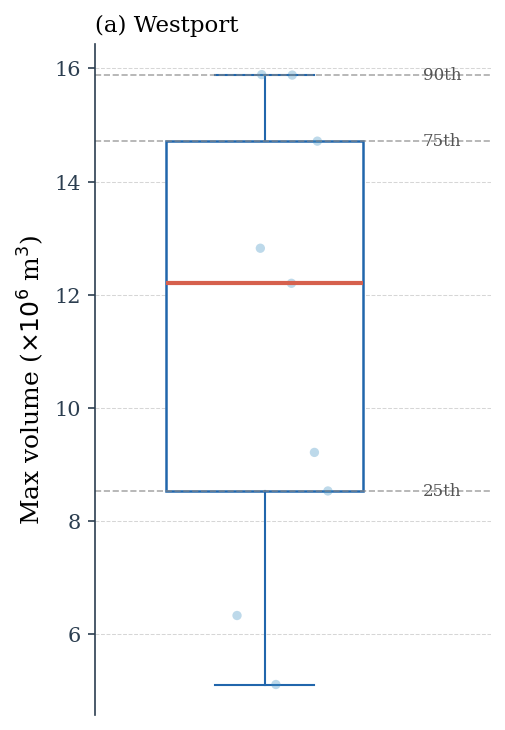

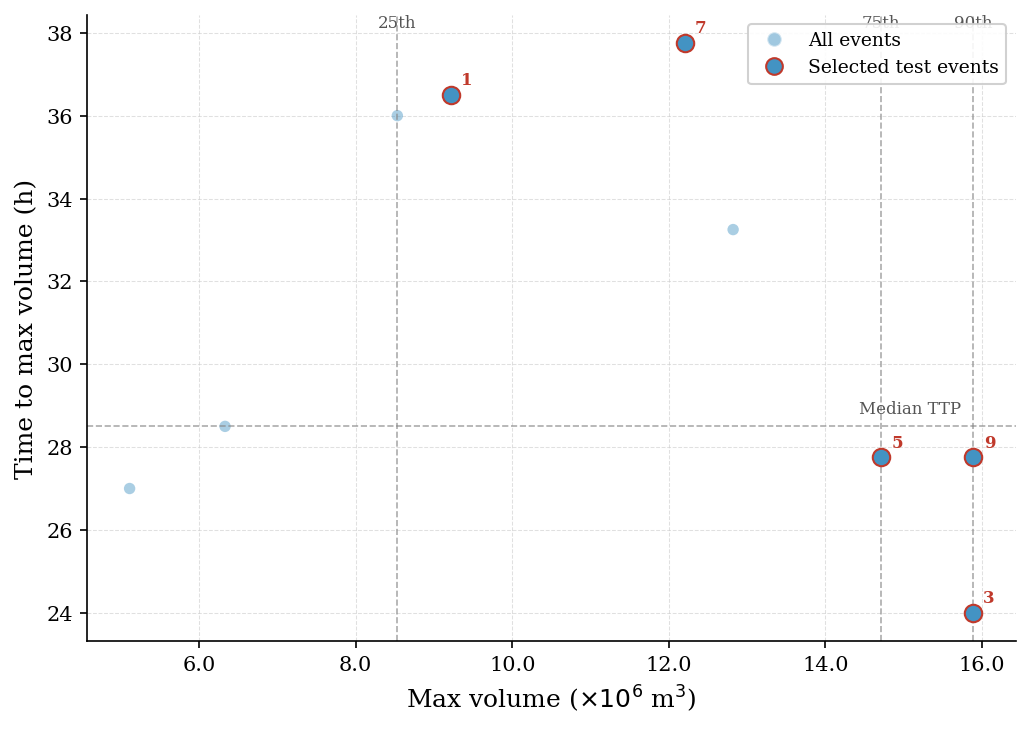


Percentile thresholds:
  25th (low/medium boundary):   8.533 × 10⁶ m³
  75th (medium/high boundary):  14.714 × 10⁶ m³
  90th (high/extreme boundary): 15.883 × 10⁶ m³
  Median time to peak:          28.5 h

Selected test events (5 total):
 event_id  max_volume_m3  time_to_peak_h  combination  event_duration_hours
        1      9213877.0           36.50  medium-slow                 66.25
        3     15881347.0           24.00    high-fast                 49.25
        5     14714117.0           27.75  medium-fast                 79.25
        7     12202240.0           37.75  medium-slow                 66.25
        9     15889772.0           27.75 extreme-fast                 78.75

Validation event (ID 8):
 event_id  max_volume_m3  time_to_peak_h combination  event_duration_hours
        8     12821648.0           33.25 medium-slow                 77.75


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
GRAPH_OUTPUT_DIR = f"/home/91/23016891/projects/carlisle/out"

peaks_df = pd.read_csv(os.path.join(GRAPH_OUTPUT_DIR, "carlisle",  "event_peaks.csv"))


# ── Event classification ──────────────────────────────────────────────────────
p25      = peaks_df["peak_volume"].quantile(0.25)
p75      = peaks_df["peak_volume"].quantile(0.75)
p90      = peaks_df["peak_volume"].quantile(0.90)
p_med_ttp = peaks_df["peak_volume_timestep"].median()

def classify_volume(v):
    if v > p90:  return "extreme"
    if v > p75:  return "high"
    if v >= p25: return "medium"
    return "low"

peaks_df["volume_class"] = peaks_df["peak_volume"].apply(classify_volume)
peaks_df["ttp_class"]    = np.where(
    peaks_df["peak_volume_timestep"] <= p_med_ttp, "fast", "slow"
)
peaks_df["combination"]  = peaks_df["volume_class"] + "-" + peaks_df["ttp_class"]

# ── Test event selection ──────────────────────────────────────────────────────
selected_ids = []

# 2 extreme events: highest two peak volumes above 90th percentile
extreme_events = (peaks_df[peaks_df["volume_class"] == "extreme"]
                  .nlargest(2, "peak_volume"))
selected_ids.extend(extreme_events["event_id"].tolist())

# 2 events per combination for medium and high bands
for combo in ["medium-fast", "medium-slow", "high-fast", "high-slow"]:
    pool = peaks_df[
        (peaks_df["combination"] == combo) &
        (~peaks_df["event_id"].isin(selected_ids))
    ]
    if len(pool) >= 2:
        median_v = pool["peak_volume"].median()
        chosen   = pool.iloc[(pool["peak_volume"] - median_v).abs().argsort()[:2]]
    else:
        chosen = pool
    selected_ids.extend(chosen["event_id"].tolist())

peaks_df["selected"] = peaks_df["event_id"].isin(selected_ids)

# ── Save selected events to CSV ───────────────────────────────────────────────
peaks_df[peaks_df["selected"]][[
    "event_id", "peak_volume", "peak_volume_timestep",
    "volume_class", "ttp_class", "combination"
]].rename(columns={
    "peak_volume":          "max_volume_m3",
    "peak_volume_timestep": "time_to_max_volume_hours",
}).to_csv(os.path.join(GRAPH_OUTPUT_DIR, "selected_test_events.csv"), index=False)

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
    "figure.dpi":       150,
    "axes.linewidth":   0.8,
    "grid.linewidth":   0.5,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

DOT_COLOR      = "#4393c3"   # uniform colour for all dots
SEL_EDGE_COLOR = "#c0392b"   # red outline for selected events
SEL_COLOR      = "#c0392b"


# ── Figure 1: Boxplot + jitter — peak inundation volume ─────────────────────
fig, ax = plt.subplots(figsize=(3.5, 5))

volumes = peaks_df["peak_volume"].values / 1e6

# Boxplot
bp = ax.boxplot(
    volumes, vert=True, patch_artist=True, widths=0.35,
    boxprops=dict(facecolor="white", edgecolor="#2166ac", linewidth=1.2),
    medianprops=dict(color="#d6604d", linewidth=2),
    whiskerprops=dict(color="#2166ac", linewidth=1.0),
    capprops=dict(color="#2166ac", linewidth=1.0),
    flierprops=dict(marker="o", markerfacecolor="#bbbbbb",
                    markeredgewidth=0, markersize=4, alpha=0.6),
)

# Jittered strip
np.random.seed(0)
x_jitter = np.random.normal(1, 0.05, size=len(volumes))
ax.scatter(x_jitter, volumes, color=DOT_COLOR, alpha=0.35,
           s=20, edgecolors="none", zorder=2)

# Percentile threshold lines
for val, label in [(p25/1e6, "25th"), (p75/1e6, "75th"), (p90/1e6, "90th")]:
    ax.axhline(val, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.text(1.28, val, label, fontsize=8, va="center", color="#555555")

ax.set_xticks([])
ax.set_xlim(0.7, 1.4)
ax.set_ylabel("Max volume ($\\times 10^6$ m$^3$)", fontsize=12)
ax.set_title("(a) Westport", loc="left", fontsize=11, pad=6)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#cccccc", alpha=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#2c3e50")
ax.tick_params(colors="#2c3e50", labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_OUTPUT_DIR,"carlisle", "fig_peak_volume_boxplot.png"))
plt.show()


# ── Figure 2: Scatter — volume vs time to peak, selected events labelled ──────
fig, ax = plt.subplots(figsize=(7, 5))

# All events — uniform colour and shape
not_selected = peaks_df[~peaks_df["selected"]]
ax.scatter(
    not_selected["peak_volume"] / 1e6,
    not_selected["peak_volume_timestep"],
    color=DOT_COLOR, s=30, alpha=0.45, edgecolors="none", zorder=2,
)

# Selected events — same colour, red outline, slightly larger
selected = peaks_df[peaks_df["selected"]]
ax.scatter(
    selected["peak_volume"] / 1e6,
    selected["peak_volume_timestep"],
    color=DOT_COLOR, s=70, alpha=1.0,
    edgecolors=SEL_EDGE_COLOR, linewidth=1.0, zorder=5,
)

# Label selected events by event_id with a small offset to avoid overlap
for _, row in selected.iterrows():
    ax.annotate(
        str(row["event_id"]),
        xy=(row["peak_volume"] / 1e6, row["peak_volume_timestep"]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=8, color=SEL_EDGE_COLOR, fontweight="bold",
    )

# Threshold lines
ax.axhline(p_med_ttp, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
ax.text(peaks_df["peak_volume"].max() / 1e6 * 0.99, p_med_ttp + 0.3,
        "Median TTP", fontsize=8, ha="right", color="#555555")
for val, label in [(p25/1e6, "25th"), (p75/1e6, "75th"), (p90/1e6, "90th")]:
    ax.axvline(val, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.text(val, peaks_df["peak_volume_timestep"].max() * 1.01,
            label, fontsize=8, ha="center", color="#555555")

# Legend
handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=DOT_COLOR,
               markersize=7, alpha=0.5, label="All events"),
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=DOT_COLOR,
               markeredgecolor=SEL_EDGE_COLOR, markeredgewidth=1.0,
               markersize=8, label="Selected test events"),
]
ax.legend(handles=handles, fontsize=9, frameon=True,
          framealpha=0.9, edgecolor="#cccccc", loc="upper right")

ax.set_xlabel("Max volume ($\\times 10^6$ m$^3$)", fontsize=12)
ax.set_ylabel("Time to max volume (h)", fontsize=12)
# ax.set_title("(b) Test event selection", loc="left", fontsize=11, pad=6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#cccccc", alpha=0.6)
ax.xaxis.grid(True, linestyle="--", linewidth=0.5, color="#cccccc", alpha=0.6)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_OUTPUT_DIR,"carlisle", "fig_test_event_selection.png"))
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"\nPercentile thresholds:")
print(f"  25th (low/medium boundary):   {p25/1e6:.3f} × 10⁶ m³")
print(f"  75th (medium/high boundary):  {p75/1e6:.3f} × 10⁶ m³")
print(f"  90th (high/extreme boundary): {p90/1e6:.3f} × 10⁶ m³")
print(f"  Median time to peak:          {p_med_ttp:.1f} h")

print(f"\nSelected test events ({len(selected_ids)} total):")
print(peaks_df[peaks_df["selected"]][[
    "event_id", "peak_volume", "peak_volume_timestep", "combination", "event_duration_hours"
]].rename(columns={
    "peak_volume":          "max_volume_m3",
    "peak_volume_timestep": "time_to_peak_h",
}).to_string(index=False))

# What's peak volume and time to peak for event 8 (the validation event)?
print("\nValidation event (ID 8):")
print(peaks_df[peaks_df["event_id"] == 8][[
    "event_id", "peak_volume", "peak_volume_timestep", "combination", "event_duration_hours"
]].rename(columns={
    "peak_volume":          "max_volume_m3",
    "peak_volume_timestep": "time_to_peak_h",
}).to_string(index=False))


In [9]:
#Read a flood map from carlisle and get the coordinates of the bounding box. 

event_name = event_name_map[event_index_map[1]]
sample_flood_map = f"{FLOOD_MAPS_DIR}/{event_name}/{event_name}-0000.wd"
import rasterio
with rasterio.open(sample_flood_map) as src:
    bounds = src.bounds
    crs = src.crs
    
print (f"Bounding box coordinates: {bounds}")
print (f"Coordinate reference system: {crs}")

Bounding box coordinates: BoundingBox(left=338500.0, bottom=554700.0, right=343255.0, top=557755.0)
Coordinate reference system: None
